In [21]:
import pandas as pd

df = pd.read_csv('../data/churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
df.shape

(7043, 21)

In [23]:
df .columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [26]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [27]:
df.columns = df.columns.str.strip()

In [28]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Insight:
X% of customers have churned.

In [29]:
df.columns = df.columns.str.strip()

In [30]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [31]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Insight:
Customers with month-to-month contracts have the highest churn rate.
Long-term contracts (1–2 years) have much lower churn.

In [32]:
df['CustomerType'] = df['tenure'].apply(lambda x: 'New' if x < 12 else 'Old')

pd.crosstab(df['CustomerType'], df['Churn'], normalize='index') * 100

Churn,No,Yes
CustomerType,,
New,51.715805,48.284195
Old,82.509047,17.490953


Insight:
New customers (less than 12 months) churn more than long-term customers.

In [33]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Insight:
Customers without tech support have a higher churn rate.

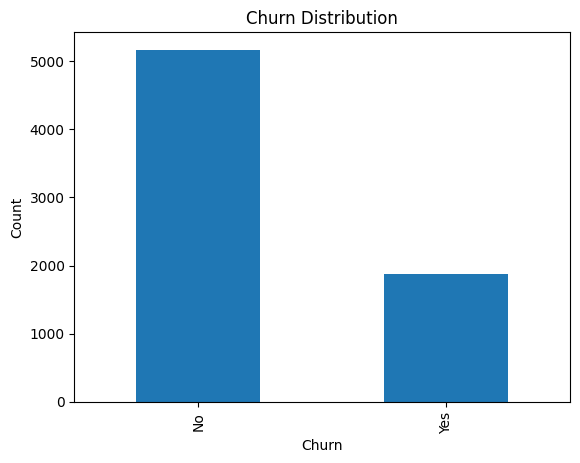

In [34]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

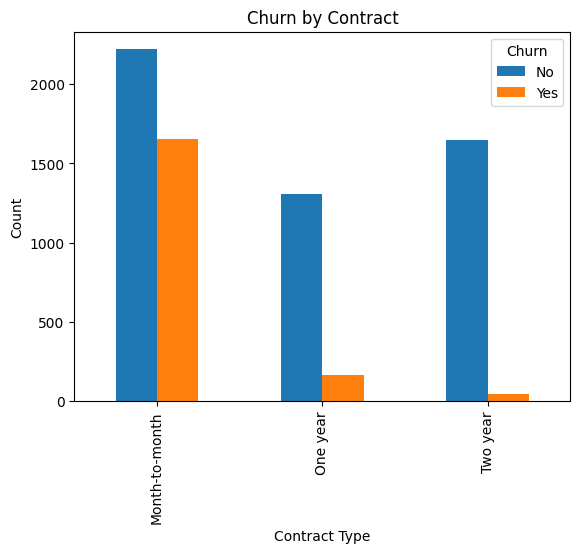

In [35]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')

plt.title("Churn by Contract")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

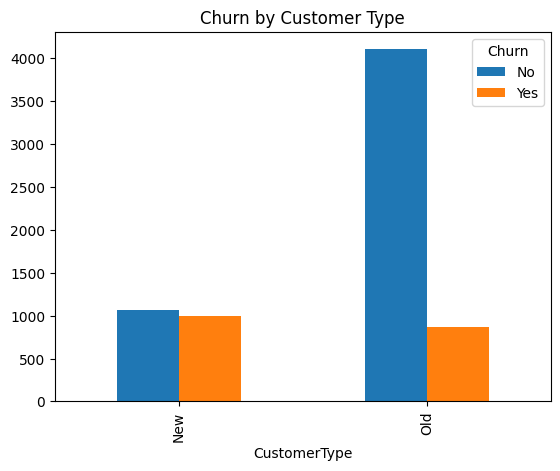

In [36]:
pd.crosstab(df['CustomerType'], df['Churn']).plot(kind='bar')

plt.title("Churn by Customer Type")
plt.show()

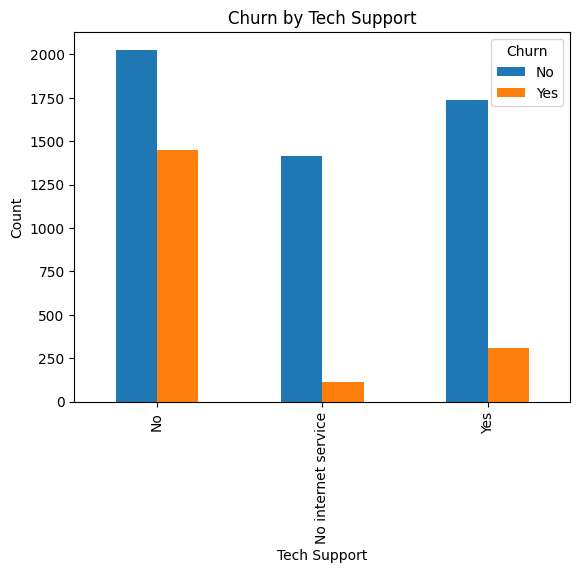

In [37]:
pd.crosstab(df['TechSupport'], df['Churn']).plot(kind='bar')
plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Count")
plt.show()

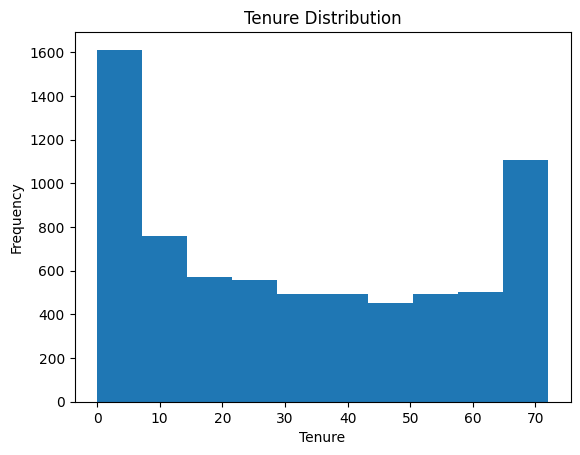

In [38]:
df['tenure'].plot(kind='hist')
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

In [39]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'CustomerType'],
      dtype='str')

Target column is: Churn_Yes
Model Accuracy: 0.7842441447835344


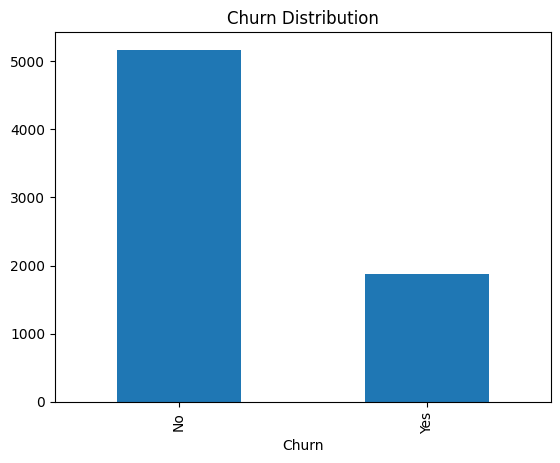

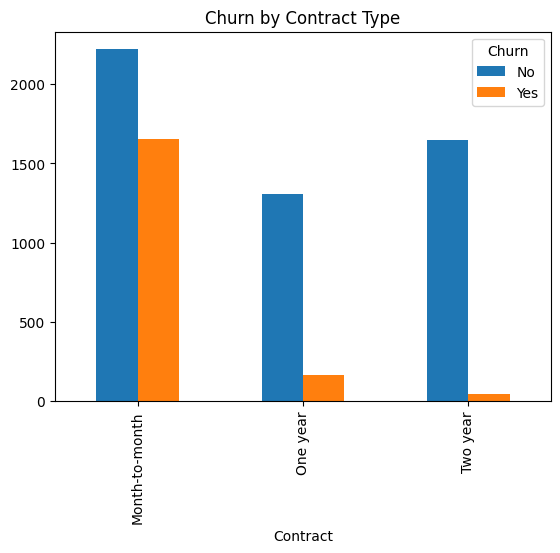

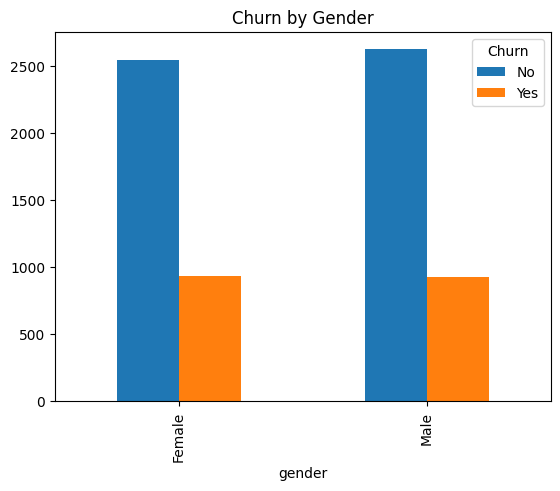

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Convert categorical to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Remove spaces from column names (important)
df_encoded.columns = df_encoded.columns.str.strip()

# Find churn column automatically
target_col = None
for col in df_encoded.columns:
    if 'Churn' in col:
        target_col = col
        break

print("Target column is:", target_col)

# Features and target
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()
import pandas as pd

pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title("Churn by Contract Type")
plt.show()
pd.crosstab(df['gender'], df['Churn']).plot(kind='bar')
plt.title("Churn by Gender")
plt.show()